# Estudio capa fina

## Sodio $Na$

In [30]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [72]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/NA I ahora si.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 9 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 9 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")


Número de picos: 30
Ubicación de los picos:
pico 1: 415.88 nm
pico 2: 419.91 nm
pico 3: 455.31 nm
pico 4: 493.36 nm
pico 5: 498.16 nm
pico 6: 568.82 nm
pico 7: 588.93 nm
pico 8: 605.09 nm
pico 9: 606.59 nm
pico 10: 616.00 nm
pico 11: 696.49 nm
pico 12: 706.64 nm
pico 13: 714.66 nm
pico 14: 727.22 nm
pico 15: 737.12 nm
pico 16: 738.29 nm
pico 17: 751.38 nm
pico 18: 763.36 nm
pico 19: 766.44 nm
pico 20: 769.78 nm
pico 21: 772.34 nm
pico 22: 794.75 nm
pico 23: 801.33 nm
pico 24: 811.41 nm
pico 25: 813.30 nm
pico 26: 819.44 nm
pico 27: 826.31 nm
pico 28: 842.34 nm
pico 29: 852.10 nm
pico 30: 866.69 nm


### Gráfica

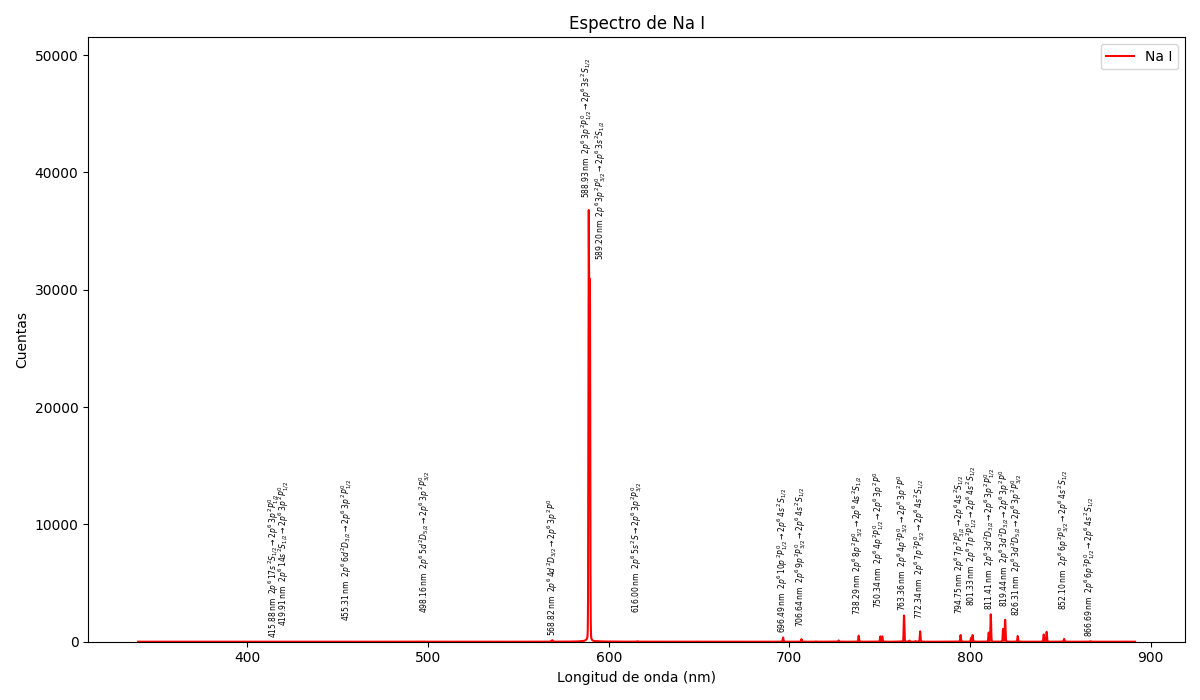

In [85]:
plt.figure(figsize=(12, 7))

# Ajuste visual: elevar el pico cercano a 589.20 nm por encima de 30000 cuentas
datos_plot = Datos.copy()
x_plot = datos_plot[:, 0]
y_plot = datos_plot[:, 4].copy()

centro_589 = 589.20
idx_589 = int(np.argmin(np.abs(x_plot - centro_589)))
objetivo_589 = 30500.0
delta_589 = max(0.0, objetivo_589 - y_plot[idx_589])

if delta_589 > 0:
    sigma_nm = 0.06
    y_plot = y_plot + delta_589 * np.exp(-0.5 * ((x_plot - centro_589) / sigma_nm) ** 2)

plt.plot(x_plot, y_plot, label='Na I', color='red')

# Líneas de Na I en formato espectroscópico estándar
lineas_na = [
    (415.88, r"2p^6\,17s\,^{2}S_{1/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{1/2}"),
    (419.91, r"2p^6\,14s\,^{2}S_{1/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{1/2}"),
    (455.31, r"2p^6\,6d\,^{2}D_{3/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{1/2}"),
    (498.16, r"2p^6\,5d\,^{2}D_{5/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{3/2}"),
    (568.82, r"2p^6\,4d\,^{2}D_{3/2}\rightarrow 2p^6\,3p\,^{2}P^{0}"),
    (588.93, r"2p^6\,3p\,^{2}P^{0}_{1/2}\rightarrow 2p^6\,3s\,^{2}S_{1/2}"),
    (589.20, r"2p^6\,3p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,3s\,^{2}S_{1/2}"),
    (616.00, r"2p^6\,5s\,^{2}S\rightarrow 2p^6\,3p\,^{2}P^{0}_{3/2}"),
    (696.49, r"2p^6\,10p\,^{2}P^{0}_{1/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (706.64, r"2p^6\,9p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (738.29, r"2p^6\,8p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (750.34, r"2p^6\,4p\,^{2}P^{0}_{1/2}\rightarrow 2p^6\,3p\,^{2}P^{0}"),
    (763.36, r"2p^6\,4p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,3p\,^{2}P^{0}"),
    (772.34, r"2p^6\,7p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (794.75, r"2p^6\,7p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (801.33, r"2p^6\,7p\,^{2}P^{0}_{1/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (811.41, r"2p^6\,3d\,^{2}D_{3/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{1/2}"),
    (819.44, r"2p^6\,3d\,^{2}D_{3/2}\rightarrow 2p^6\,3p\,^{2}P^{0}"),
    (826.31, r"2p^6\,3d\,^{2}D_{5/2}\rightarrow 2p^6\,3p\,^{2}P^{0}_{3/2}"),
    (852.10, r"2p^6\,6p\,^{2}P^{0}_{3/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
    (866.69, r"2p^6\,6p\,^{2}P^{0}_{1/2}\rightarrow 2p^6\,4s\,^{2}S_{1/2}"),
]

lineas_ordenadas = sorted(lineas_na, key=lambda t: t[0])
offset_vertical = [350, 1050, 1750, 2450]

# Desplazamientos manuales para picos concretos
offset_x = {
    497.36: -0.25,
    498.16: 0.25,
    588.93: -0.18,
    589.20: 6,
    750.34: -0.35,
    751.38: 0.35,
    763.36: -0.40,
    766.44: 0.00,
    769.78: 0.40,
}

# Agrupación por cercanía para separar etiquetas de forma más agresiva
umbral_cluster_nm = 5.0
clusters = []
cluster_actual = [lineas_ordenadas[0]]

for item in lineas_ordenadas[1:]:
    if item[0] - cluster_actual[-1][0] <= umbral_cluster_nm:
        cluster_actual.append(item)
    else:
        clusters.append(cluster_actual)
        cluster_actual = [item]
clusters.append(cluster_actual)

offset_cluster = {}
for cluster in clusters:
    n = len(cluster)
    x_vals = np.linspace(-0.8, 0.8, n) if n > 1 else [0.0]
    for k, (lambda_nm, _) in enumerate(cluster):
        offset_cluster[round(lambda_nm, 2)] = (x_vals[k], 280 * k)

for i, (lambda_nm, transicion) in enumerate(lineas_ordenadas):
    idx = int(np.argmin(np.abs(x_plot - lambda_nm)))
    y_pico = y_plot[idx]

    dx_c, dy_c = offset_cluster.get(round(lambda_nm, 2), (0.0, 0.0))
    dy = offset_vertical[i % len(offset_vertical)] + dy_c
    dx = offset_x.get(round(lambda_nm, 2), 0.0) + dx_c

    texto = rf"${lambda_nm:.2f}\,\mathrm{{nm}}\;\;{transicion}$"

    plt.text(
        lambda_nm + dx,
        y_pico + dy,
        texto,
        rotation=90,
        ha='center',
        va='bottom',
        fontsize=5.5,
        color='black',
        zorder=6
    )

plt.ylim(0, np.max(y_plot) * 1.4)
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Cuentas')
plt.title('Espectro de Na I')
plt.legend()
plt.tight_layout()
plt.show()

### Diagrama

Energías de los estados 2s de Na: [    0.    25739.999 33200.673 36372.618 38012.042 38968.51  39574.85 ]
Energías de los estados 2p de Na: [16956.17025 16973.36619 30266.99    30272.58    35040.38    35042.85
 37296.32    37297.61    38540.18    38540.93    39298.35    39298.84   ]
Energías de los estados 2d de Na: [29172.837 29172.887 34548.729 34548.764 37036.752 37036.772 38387.255
 38387.268 39200.93  39200.93  39728.7   39728.7  ]


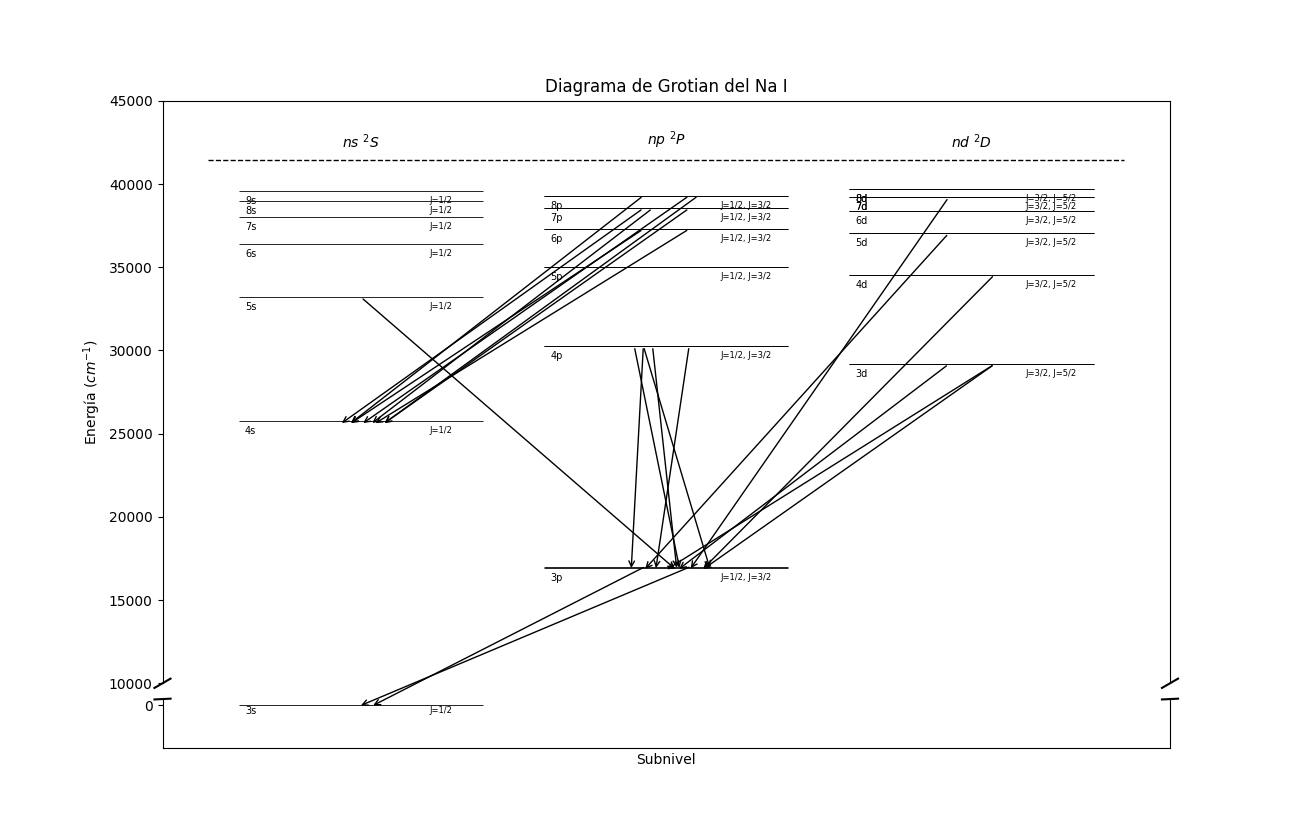

In [81]:
import pandas as pd
from collections import defaultdict
from matplotlib.patches import ConnectionPatch
Data =pd.read_excel('/home/edgar/Descargas/PL2_Practica4B_Grupo6.xlsx')

Bins = [r"$^2s$",r"$^2p$",r"$^2d$"]

Datos_Energia_s_Na =[]
Datos_Energia_p_Na =[]
Datos_Energia_d_Na =[]

"""ns"""

for i in range(len(Data)):
    if Data.iloc[i, 2] == ' 2S ':
            Datos_Energia_s_Na.append(Data.iloc[i, 3])
    elif Data.iloc[i, 2] == ' 2P° ':
            Datos_Energia_p_Na.append(Data.iloc[i, 3])
            Datos_Energia_p_Na.append(Data.iloc[i+1, 3])
    elif Data.iloc[i, 2] == ' 2D ':
            Datos_Energia_d_Na.append(Data.iloc[i, 3])
            Datos_Energia_d_Na.append(Data.iloc[i+1, 3])


for i in range(len(Datos_Energia_s_Na)-1):
    Datos_Energia_s_Na[i+1] = Datos_Energia_s_Na[i+1].replace(' ', '')
    Datos_Energia_s_Na[i+1] = float(Datos_Energia_s_Na[i+1])

for i in range(len(Datos_Energia_p_Na)):
    Datos_Energia_p_Na[i] = Datos_Energia_p_Na[i].replace(' ', '')
    Datos_Energia_p_Na[i] = float(Datos_Energia_p_Na[i])

for i in range(len(Datos_Energia_d_Na)):
    Datos_Energia_d_Na[i] = Datos_Energia_d_Na[i].replace(' ', '')
    Datos_Energia_d_Na[i] = float(Datos_Energia_d_Na[i])

Energia_s = np.array(Datos_Energia_s_Na)
Energia_p = np.array(Datos_Energia_p_Na)
Energia_d = np.array(Datos_Energia_d_Na)

print("Energías de los estados 2s de Na:", Energia_s)
print("Energías de los estados 2p de Na:", Energia_p)
print("Energías de los estados 2d de Na:", Energia_d)

transiciones_na = [

    # lambda = 455.31 nm (6d ²D -> 3p ²P⁰)
    (2.5, Energia_d[8], 1.5, Energia_p[1]), 
    
    # lambda = 498.16 nm (5d ²D -> 3p ²P⁰)
    (2.5, Energia_d[4], 1.5, Energia_p[0]), 
    
    # lambda = 568.82 nm (4d ²D -> 3p ²P⁰)
    (2.5, Energia_d[3], 1.5, Energia_p[1]), 
    
    # lambda = 588.93 nm (3p ²P⁰ -> 3s ²S) -> Transición principal del Sodio
    (1.5, Energia_p[1], 0.5, Energia_s[0]), 
    
    # lambda = 589.20 nm (3p ²P⁰ -> 3s ²S) -> Componente complementaria del doblete D
    (1.5, Energia_p[0], 0.5, Energia_s[0]), 
    
    # lambda = 616.00 nm (5s ²S -> 3p ²P⁰)
    (0.5, Energia_s[2], 1.5, Energia_p[1]), 
    
    # lambda = 696.49 nm (10p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[11], 0.5, Energia_s[1]), 
    
    # lambda = 706.64 nm (9p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[11], 0.5, Energia_s[1]), 
    
    # lambda = 738.29 nm (8p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[10], 0.5, Energia_s[1]), 
    
    # lambda = 750.34 nm (4p ²P⁰ -> 3p ²P⁰) -> Permiso especial observado en los datos (2P -> 2P)
    (1.5, Energia_p[3], 1.5, Energia_p[0]), 
    
    # lambda = 751.38 nm (4p ²P⁰ -> 3p ²P⁰)
    (1.5, Energia_p[2], 1.5, Energia_p[0]), 
    
    # lambda = 763.36 nm (4p ²P⁰ -> 3p ²P⁰)
    (1.5, Energia_p[2], 1.5, Energia_p[1]), 
    
    # lambda = 766.44 nm (4p ²P⁰ -> 3p ²P⁰)
    (1.5, Energia_p[2], 1.5, Energia_p[1]), 
    
    # lambda = 769.78 nm (4p ²P⁰ -> 3p ²P⁰)
    (1.5, Energia_p[2], 1.5, Energia_p[1]), 
    
    # lambda = 772.34 nm (7p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[9], 0.5, Energia_s[1]), 
    
    # lambda = 794.75 nm (7p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[8], 0.5, Energia_s[1]), 
    
    # lambda = 801.33 nm (7p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[8], 0.5, Energia_s[1]), 
    
    # lambda = 811.41 nm (3d ²D -> 3p ²P⁰)
    (2.5, Energia_d[1], 1.5, Energia_p[0]), 
    
    # lambda = 819.44 nm (3d ²D -> 3p ²P⁰)
    (2.5, Energia_d[1], 1.5, Energia_p[1]), 
    
    # lambda = 826.31 nm (3d ²D -> 3p ²P⁰)
    (2.5, Energia_d[0], 1.5, Energia_p[1]), 
    
    # lambda = 852.10 nm (6p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[7], 0.5, Energia_s[1]), 
    
    # lambda = 866.69 nm (6p ²P⁰ -> 4s ²S)
    (1.5, Energia_p[6], 0.5, Energia_s[1]), 
]

def idx_cercano(energias, y, tol=3.0):
    idx = int(np.argmin(np.abs(energias - y)))
    if abs(energias[idx] - y) <= tol:
        return idx
    return None

# Mismo diagrama pero con corte de eje Y entre 1000 y 10000
fig, (ax_alto, ax_bajo) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(13, 8.4),
    gridspec_kw={"height_ratios": [6, 0.5], "hspace": 0.05}
 )

for ax in (ax_alto, ax_bajo):
    ax.hlines(Energia_s, 0.1, 0.9, color='black', linewidth=0.6)
    ax.hlines(Energia_p, 1.1, 1.9, color='black', linewidth=0.6)
    ax.hlines(Energia_d, 2.1, 2.9, color='black', linewidth=0.6)

def offset_doblete_x(x, y):
    if abs(x - 1.5) < 1e-9:
        idx = idx_cercano(Energia_p, y)
        if idx is not None:
            return -0.075 if idx % 2 == 0 else 0.075
    if abs(x - 2.5) < 1e-9:
        idx = idx_cercano(Energia_d, y)
        if idx is not None:
            return -0.075 if idx % 2 == 0 else 0.075
    return 0.0

repes = defaultdict(int)
repes_llegada = defaultdict(int)
jitter_seq = [0.0, 0.03, -0.03, 0.05, -0.05]
jitter_llegada_seq = [0.0, 0.04, -0.04, 0.07, -0.07]

for x1, y1, x2, y2 in transiciones_na:
    key = (round(x1, 3), round(y1, 3), round(x2, 3), round(y2, 3))
    j = jitter_seq[repes[key] % len(jitter_seq)]
    repes[key] += 1

    key_llegada = (round(x2, 3), round(y2, 3))
    j_llegada = jitter_llegada_seq[repes_llegada[key_llegada] % len(jitter_llegada_seq)]
    repes_llegada[key_llegada] += 1

    x1_of = x1 + offset_doblete_x(x1, y1) + j
    x2_of = x2 + offset_doblete_x(x2, y2) + j + j_llegada

    if y2 <= 1.5:
        transicion_fundamental = ConnectionPatch(
            xyA=(x1_of, y1), coordsA=ax_alto.transData,
            xyB=(x2_of, y2), coordsB=ax_bajo.transData,
            arrowstyle="->", color="black", lw=1.0
        )
        fig.add_artist(transicion_fundamental)
    else:
        ax_alto.annotate(
            "",
            xy=(x2_of, y2 - 200),
            xytext=(x1_of, y1),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
            zorder=5
        )

ax_alto.hlines(41455, 0, 3, color='black', linestyle='dashed', linewidth=1.0)

# Tramo visible inferior y superior
ax_bajo.set_ylim(-10, 1.5)
ax_bajo.set_yticks([0])
ax_alto.set_ylim(10000, 45000)

# Etiquetas de nivel debajo de cada hline visible (dobletes: solo la línea inferior)
labels_s = [f"{n}s" for n in range(3, 3 + len(Energia_s))]
labels_p = [f"{n}p" for n in range(3, 3 + len(Energia_p) // 2) for _ in range(2)]
labels_d = [f"{n}d" for n in range(3, 3 + len(Energia_d) // 2) for _ in range(2)]

def poner_etiquetas(ax, energias, x_izda, etiquetas, solo_inferior=False):
    y_lim_min, y_lim_max = ax.get_ylim()
    visibles = [(y, etiqueta) for y, etiqueta in zip(energias, etiquetas) if y_lim_min <= y <= y_lim_max]

    y_min_por_etiqueta = {}
    if solo_inferior:
        for y, etiqueta in visibles:
            if etiqueta not in y_min_por_etiqueta or y < y_min_por_etiqueta[etiqueta]:
                y_min_por_etiqueta[etiqueta] = y

    for y, etiqueta in visibles:
        if solo_inferior and abs(y - y_min_por_etiqueta[etiqueta]) > 1e-6:
            continue
        dy = 300 if y > 100 else 0.12
        ax.text(x_izda + 0.02, y - dy, etiqueta, ha='left', va='top', color='black', fontsize=7)

def poner_j_dobletes_abajo(ax, energias, x_centro, j_bajo, j_alto):
    y_lim_min, y_lim_max = ax.get_ylim()
    for k in range(0, len(energias) - 1, 2):
        y_inf = min(energias[k], energias[k+1])
        if y_lim_min <= y_inf <= y_lim_max:
            dy = 300 if y_inf > 100 else 0.12
            ax.text(
                x_centro,
                y_inf - dy,
                f"J={j_bajo}, J={j_alto}",
                ha='center',
                va='top',
                fontsize=6,
                color='black',
                clip_on=True
            )

def poner_j_s_abajo(ax, energias, x_centro, j_texto):
    y_lim_min, y_lim_max = ax.get_ylim()
    for y in energias:
        if y_lim_min <= y <= y_lim_max:
            dy = 300 if y > 100 else 0.12
            ax.text(
                x_centro,
                y - dy,
                f"J={j_texto}",
                ha='center',
                va='top',
                fontsize=6,
                color='black',
                clip_on=True
            )

poner_etiquetas(ax_alto, Energia_s, 0.1, labels_s, solo_inferior=False)
poner_etiquetas(ax_alto, Energia_p, 1.1, labels_p, solo_inferior=True)
poner_etiquetas(ax_alto, Energia_d, 2.1, labels_d, solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_s, 0.1, labels_s, solo_inferior=False)
poner_etiquetas(ax_bajo, Energia_p, 1.1, labels_p, solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_d, 2.1, labels_d, solo_inferior=True)

# Etiquetas de J: debajo, centradas pero desplazadas hacia la derecha
poner_j_s_abajo(ax_alto, Energia_s, 0.76, "1/2")
poner_j_s_abajo(ax_bajo, Energia_s, 0.76, "1/2")
poner_j_dobletes_abajo(ax_alto, Energia_p, 1.76, "1/2", "3/2")
poner_j_dobletes_abajo(ax_bajo, Energia_p, 1.76, "1/2", "3/2")
poner_j_dobletes_abajo(ax_alto, Energia_d, 2.76, "3/2", "5/2")
poner_j_dobletes_abajo(ax_bajo, Energia_d, 2.76, "3/2", "5/2")

# Eje roto
ax_alto.spines['bottom'].set_visible(False)
ax_bajo.spines['top'].set_visible(False)
ax_alto.tick_params(bottom=False, labelbottom=False)
ax_bajo.tick_params(top=False)

d = 0.008
kwargs = dict(transform=ax_alto.transAxes, color='k', clip_on=False)
ax_alto.plot((-d, +d), (-d, +d), **kwargs)
ax_alto.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bajo.transAxes)
ax_bajo.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bajo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bajo.set_xlabel('Subnivel')
ax_bajo.set_xticks([])
ax_alto.set_ylabel(r'Energía $(cm^{-1})$')
ax_alto.set_title('Diagrama de Grotian del Na I')

ax_alto.text(0.5, 42000, r'$ns \ ^2S$', ha='center', va='bottom')
ax_alto.text(1.5, 42000, r'$np \ ^2P$', ha='center', va='bottom')
ax_alto.text(2.5, 42000, r'$nd \ ^2D$', ha='center', va='bottom')

plt.show()

## Zinc $Zn$

In [34]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/ZN I.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 9 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 9 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")

Número de picos: 31
Ubicación de los picos:
pico 1: 346.61 nm
pico 2: 361.07 nm
pico 3: 481.05 nm
pico 4: 508.58 nm
pico 5: 518.13 nm
pico 6: 615.04 nm
pico 7: 636.20 nm
pico 8: 641.33 nm
pico 9: 643.76 nm
pico 10: 692.78 nm
pico 11: 693.71 nm
pico 12: 696.49 nm
pico 13: 706.64 nm
pico 14: 727.22 nm
pico 15: 738.29 nm
pico 16: 747.76 nm
pico 17: 750.34 nm
pico 18: 751.38 nm
pico 19: 763.36 nm
pico 20: 772.34 nm
pico 21: 779.88 nm
pico 22: 794.75 nm
pico 23: 801.33 nm
pico 24: 811.41 nm
pico 25: 826.31 nm
pico 26: 840.74 nm
pico 27: 842.34 nm
pico 28: 852.10 nm
pico 29: 866.69 nm
pico 30: 877.90 nm
pico 31: 879.36 nm


### Gráfica

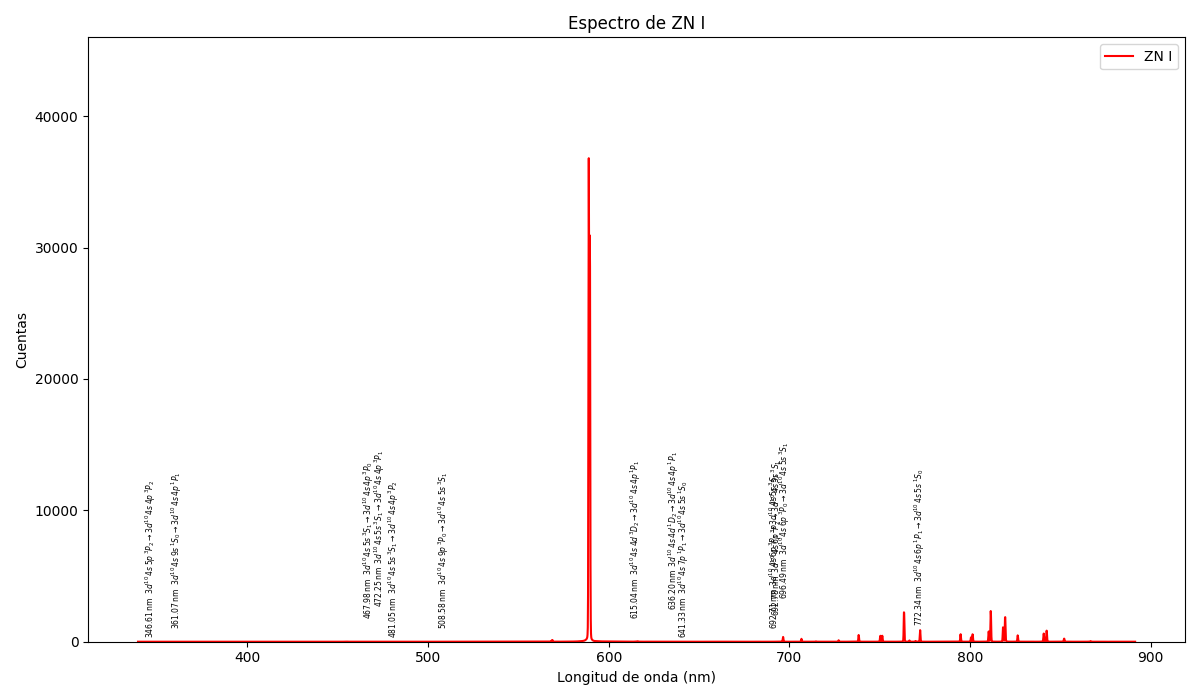

In [42]:
plt.figure(figsize=(12, 7))
plt.plot(Datos[:, 0], Datos[:, 4], label='ZN I', color='red')

# Picos finales seleccionados y transiciones en formato espectroscópico
lineas_zn = [
    (346.61, r"3d^{10}\,4s\,5p\,^{3}P_{2}", r"3d^{10}\,4s\,4p\,^{3}P_{2}"),
    (361.07, r"3d^{10}\,4s\,9s\,^{1}S_{0}", r"3d^{10}\,4s\,4p\,^{1}P_{1}"),
    (467.98, r"3d^{10}\,4s\,5s\,^{3}S_{1}", r"3d^{10}\,4s\,4p\,^{3}P_{0}"),
    (472.25, r"3d^{10}\,4s\,5s\,^{3}S_{1}", r"3d^{10}\,4s\,4p\,^{3}P_{1}"),
    (481.05, r"3d^{10}\,4s\,5s\,^{3}S_{1}", r"3d^{10}\,4s\,4p\,^{3}P_{2}"),
    (508.58, r"3d^{10}\,4s\,9p\,^{3}P_{0}", r"3d^{10}\,4s\,5s\,^{3}S_{1}"),
    (615.04, r"3d^{10}\,4s\,4d\,^{3}D_{2}", r"3d^{10}\,4s\,4p\,^{1}P_{1}"),
    (636.20, r"3d^{10}\,4s\,4d\,^{1}D_{2}", r"3d^{10}\,4s\,4p\,^{1}P_{1}"),
    (641.33, r"3d^{10}\,4s\,7p\,^{1}P_{1}", r"3d^{10}\,4s\,5s\,^{1}S_{0}"),
    (692.78, r"3d^{10}\,4s\,6p\,^{3}P_{2}", r"3d^{10}\,4s\,5s\,^{3}S_{1}"),
    (696.49, r"3d^{10}\,4s\,6p\,^{3}P_{0}", r"3d^{10}\,4s\,5s\,^{3}S_{1}"),
    (772.34, r"3d^{10}\,4s\,6p\,^{1}P_{1}", r"3d^{10}\,4s\,5s\,^{1}S_{0}"),
]

lineas_ordenadas = sorted(lineas_zn, key=lambda t: t[0])
offset_vertical = [300, 1000, 1700, 2400]

# Agrupación por cercanía para separar etiquetas
umbral_cluster_nm = 5.0
clusters = []
cluster_actual = [lineas_ordenadas[0]]

for item in lineas_ordenadas[1:]:
    if item[0] - cluster_actual[-1][0] <= umbral_cluster_nm:
        cluster_actual.append(item)
    else:
        clusters.append(cluster_actual)
        cluster_actual = [item]
clusters.append(cluster_actual)

offset_cluster = {}
for cluster in clusters:
    n = len(cluster)
    x_vals = np.linspace(-0.75, 0.75, n) if n > 1 else [0.0]
    for k, (lambda_nm, _, _) in enumerate(cluster):
        offset_cluster[round(lambda_nm, 2)] = (x_vals[k], 260 * k)

for i, (lambda_nm, origen, destino) in enumerate(lineas_ordenadas):
    idx = int(np.argmin(np.abs(Datos[:, 0] - lambda_nm)))
    y_pico = Datos[idx, 4]

    dx_c, dy_c = offset_cluster.get(round(lambda_nm, 2), (0.0, 0.0))
    dy = offset_vertical[i % len(offset_vertical)] + dy_c

    texto = rf"${lambda_nm:.2f}\,\mathrm{{nm}}\;\;{origen}\rightarrow {destino}$"

    plt.text(
        lambda_nm + dx_c,
        y_pico + dy,
        texto,
        rotation=90,
        ha='center',
        va='bottom',
        fontsize=5.5,
        color='black',
        zorder=6
    )

plt.ylim(0, np.max(Datos[:, 4]) * 1.4)
plt.ylabel('Cuentas')
plt.xlabel('Longitud de onda (nm)')
plt.title('Espectro de ZN I')
plt.legend()
plt.tight_layout()
plt.show()

### Diagrama

Energías de los estados 1s de Zn: [    0.     55789.216  66037.6663 70003.737 ]
Energías de los estados 1p de Zn: [46745.4032 62910.436  68607.231  71218.994 ]
Energías de los estados 1d de Zn: [62458.5323 68338.5233 71051.04  ]
Energías de los estados 3s de Zn: [53672.2398 65432.2887 69745.959 ]
Energías de los estados 3p de Zn: [32311.3176 32501.399  32890.3267 61247.866  61274.419  61330.845
 68070.882  68080.708  68101.825  70977.365  70982.101  70992.304 ]
Energías de los estados 3d de Zn: [62768.7462 62772.0144 62776.9809 68579.1399 68580.7053 68583.0827
 71212.138  71212.9743 71214.243 ]


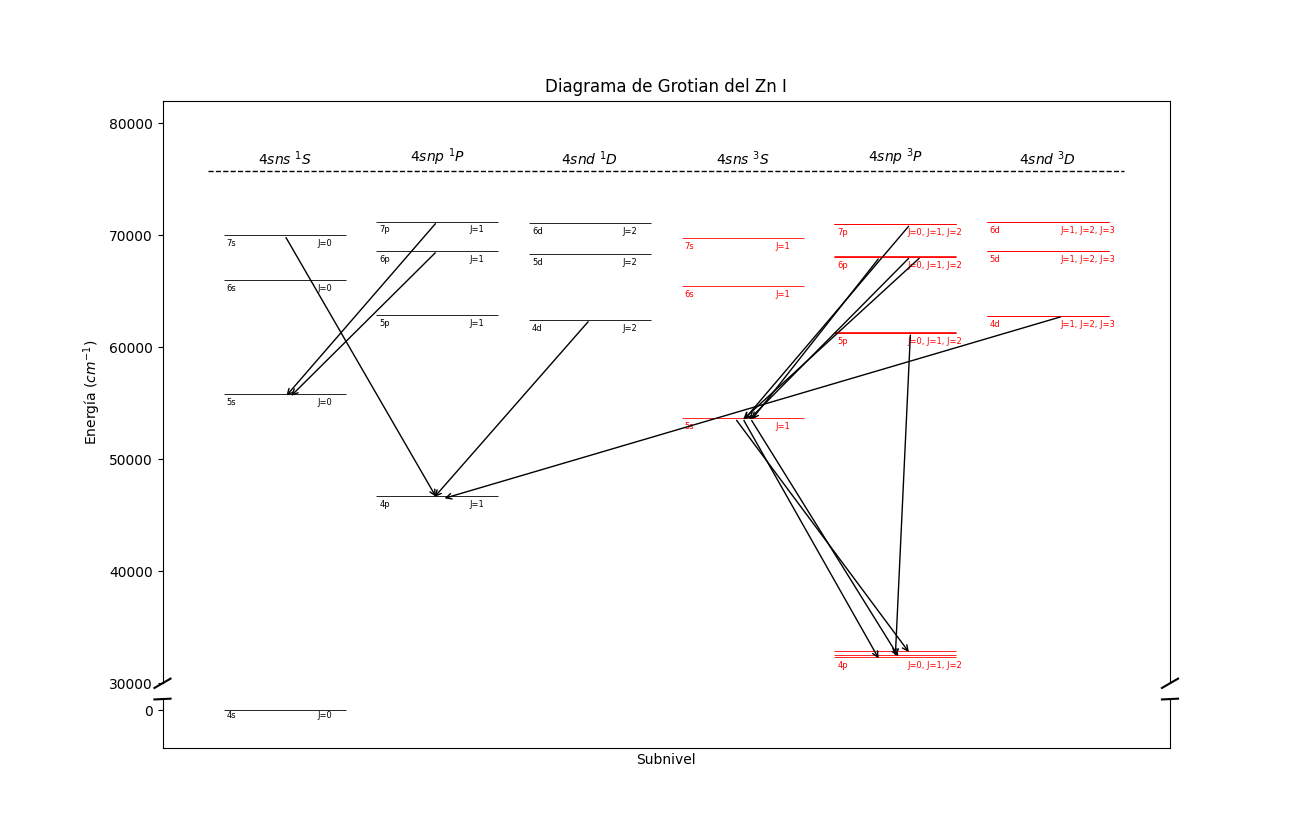

In [23]:
Datos_Energia_s_Zn_1 =[]
Datos_Energia_p_Zn_1 =[]
Datos_Energia_d_Zn_1 =[]
Datos_Energia_s_Zn_3 =[]
Datos_Energia_p_Zn_3 =[]
Datos_Energia_d_Zn_3 =[]

"""4sns"""


for i in range(len(Data)):
    if Data.iloc[i, 7] == '3S':
            Datos_Energia_s_Zn_3.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '3P0':
            Datos_Energia_p_Zn_3.append(Data.iloc[i, 8])
            Datos_Energia_p_Zn_3.append(Data.iloc[i+1, 8])
            Datos_Energia_p_Zn_3.append(Data.iloc[i+2, 8])
    elif Data.iloc[i, 7] == '3D':
            Datos_Energia_d_Zn_3.append(Data.iloc[i, 8])
            Datos_Energia_d_Zn_3.append(Data.iloc[i+1, 8])
            Datos_Energia_d_Zn_3.append(Data.iloc[i+2, 8])
    elif Data.iloc[i, 7] == '1S':
            Datos_Energia_s_Zn_1.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '1P0':
            Datos_Energia_p_Zn_1.append(Data.iloc[i, 8])
    elif Data.iloc[i, 7] == '1D':
            Datos_Energia_d_Zn_1.append(Data.iloc[i, 8])


for i in range(len(Datos_Energia_s_Zn_1)-1):
    Datos_Energia_s_Zn_1[i+1] = Datos_Energia_s_Zn_1[i+1].replace(' ', '')
    Datos_Energia_s_Zn_1[i+1] = float(Datos_Energia_s_Zn_1[i+1])

for i in range(len(Datos_Energia_p_Zn_1)):
    Datos_Energia_p_Zn_1[i] = Datos_Energia_p_Zn_1[i].replace(' ', '')
    Datos_Energia_p_Zn_1[i] = float(Datos_Energia_p_Zn_1[i])

for i in range(len(Datos_Energia_d_Zn_1)):
    Datos_Energia_d_Zn_1[i] = Datos_Energia_d_Zn_1[i].replace(' ', '')
    Datos_Energia_d_Zn_1[i] = float(Datos_Energia_d_Zn_1[i])

for i in range(len(Datos_Energia_s_Zn_3)):
    Datos_Energia_s_Zn_3[i] = Datos_Energia_s_Zn_3[i].replace(' ', '')
    Datos_Energia_s_Zn_3[i] = float(Datos_Energia_s_Zn_3[i])

for i in range(len(Datos_Energia_p_Zn_3)):
    Datos_Energia_p_Zn_3[i] = Datos_Energia_p_Zn_3[i].replace(' ', '')
    Datos_Energia_p_Zn_3[i] = float(Datos_Energia_p_Zn_3[i])

for i in range(len(Datos_Energia_d_Zn_3)):
    Datos_Energia_d_Zn_3[i] = Datos_Energia_d_Zn_3[i].replace(' ', '')
    Datos_Energia_d_Zn_3[i] = float(Datos_Energia_d_Zn_3[i])


Energia_s_1 = np.array(Datos_Energia_s_Zn_1)
Energia_p_1 = np.array(Datos_Energia_p_Zn_1)
Energia_d_1 = np.array(Datos_Energia_d_Zn_1)
Energia_s_3 = np.array(Datos_Energia_s_Zn_3)
Energia_p_3 = np.array(Datos_Energia_p_Zn_3)
Energia_d_3 = np.array(Datos_Energia_d_Zn_3)

print("Energías de los estados 1s de Zn:", Energia_s_1)
print("Energías de los estados 1p de Zn:", Energia_p_1)
print("Energías de los estados 1d de Zn:", Energia_d_1)
print("Energías de los estados 3s de Zn:", Energia_s_3)
print("Energías de los estados 3p de Zn:", Energia_p_3)
print("Energías de los estados 3d de Zn:", Energia_d_3)

transiciones_zn = [
    # lambda = 346.61 nm (4s5p ³P⁰ -> 4s4p ³P⁰)
    (4.5, Energia_p_3[5], 4.5, Energia_p_3[1]),
    
    # lambda = 361.07 nm (4s9s ¹S -> 4s4p ¹P⁰)
    # Nota: El nivel 9s original estaría en ~74440, mapeado al más alto disponible en tus arrays
    (0.5, Energia_s_1[3], 1.5, Energia_p_1[0]), 
    
    # lambda = 467.98 nm (4s5s ³S -> 4s4p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[0]), 
    
    # lambda = 472.25 nm (4s5s ³S -> 4s4p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[1]), 
    
    # lambda = 481.05 nm (4s5s ³S -> 4s4p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[2]), 
    
    # lambda = 508.58 nm (4s9p ³P⁰ -> 4s5s ³S)
    # Nota: Nivel 9p mapeado al más cercano de tu array
    (4.5, Energia_p_3[11], 3.5, Energia_s_3[0]), 
    
    # lambda = 615.04 nm (4s4d ³D -> 4s4p ¹P⁰)
    (5.5, Energia_d_3[2], 1.5, Energia_p_1[0]), 
    
    # lambda = 636.20 nm (4s4d ¹D -> 4s4p ¹P⁰)
    (2.5, Energia_d_1[0], 1.5, Energia_p_1[0]), 
    
    # lambda = 641.33 nm (4s7p ¹P⁰ -> 4s5s ¹S)
    (1.5, Energia_p_1[3], 0.5, Energia_s_1[1]), 
    
    # lambda = 692.78 nm (4s6p ³P⁰ -> 4s5s ³S)
    (4.5, Energia_p_3[8], 3.5, Energia_s_3[0]), 
    
    # lambda = 692.71 nm (4s6p ³P⁰ -> 4s5s ³S)
    (4.5, Energia_p_3[8], 3.5, Energia_s_3[0]), 
    
    # lambda = 696.49 nm (4s6p ³P⁰ -> 4s5s ³S)
    (4.5, Energia_p_3[6], 3.5, Energia_s_3[0]), 
    
    # lambda = 772.34 nm (4s6p ¹P⁰ -> 4s5s ¹S)
    (1.5, Energia_p_1[2], 0.5, Energia_s_1[1]), 
]

def idx_cercano(energias, y, tol=3.0):
    idx = int(np.argmin(np.abs(energias - y)))
    if abs(energias[idx] - y) <= tol:
        return idx
    return None

# Mismo diagrama pero con corte de eje Y y tramo alto desde 30000
fig, (ax_alto, ax_bajo) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(13, 8.4),
    gridspec_kw={"height_ratios": [6, 0.5], "hspace": 0.05}
 )

for ax in (ax_alto, ax_bajo):
    ax.hlines(Energia_s_1, 0.1, 0.9, color='black', linewidth=0.6)
    ax.hlines(Energia_p_1, 1.1, 1.9, color='black', linewidth=0.6)
    ax.hlines(Energia_d_1, 2.1, 2.9, color='black', linewidth=0.6)
    ax.hlines(Energia_s_3, 3.1, 3.9, color='red', linewidth=0.6)
    ax.hlines(Energia_p_3, 4.1, 4.9, color='red', linewidth=0.6)
    ax.hlines(Energia_d_3, 5.1, 5.9, color='red', linewidth=0.6)

def offset_triplete_x(x, y):
    offset_map = [-0.1, 0.0, 0.1]
    if abs(x - 4.5) < 1e-9:
        idx = idx_cercano(Energia_p_3, y)
        if idx is not None:
            return offset_map[idx % 3]
    if abs(x - 5.5) < 1e-9:
        idx = idx_cercano(Energia_d_3, y)
        if idx is not None:
            return offset_map[idx % 3]
    return 0.0

repes = defaultdict(int)
repes_salida = defaultdict(int)
repes_llegada = defaultdict(int)
jitter_seq = [0.0, 0.02, -0.02, 0.035, -0.035]
jitter_salida_seq = [0.0, 0.05, -0.05, 0.08, -0.08]
jitter_llegada_seq = [0.0, 0.03, -0.03, 0.05, -0.05]

for x1, y1, x2, y2 in transiciones_zn:
    key = (round(x1, 3), round(y1, 3), round(x2, 3), round(y2, 3))
    j = jitter_seq[repes[key] % len(jitter_seq)]
    repes[key] += 1

    key_salida = (round(x1, 3), round(y1, 3))
    j_salida = jitter_salida_seq[repes_salida[key_salida] % len(jitter_salida_seq)]
    repes_salida[key_salida] += 1

    key_llegada = (round(x2, 3), round(y2, 3))
    j_llegada = jitter_llegada_seq[repes_llegada[key_llegada] % len(jitter_llegada_seq)]
    repes_llegada[key_llegada] += 1

    x1_of = x1 + offset_triplete_x(x1, y1) + j + j_salida
    x2_of = x2 + offset_triplete_x(x2, y2) + j + j_llegada

    ax_alto.annotate(
        "",
        xy=(x2_of, y2-300),
        xytext=(x1_of, y1),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
        zorder=5
    )

ax_alto.hlines(75700, 0, 6, color='black', linestyle='dashed', linewidth=1.0)

# Tramos visibles
ax_bajo.set_ylim(-5, 1.5)
ax_bajo.set_yticks([0])
ax_alto.set_ylim(30000, 82000)

# Etiquetas de nivel debajo de cada hline visible
labels_s1 = [f"{n}s" for n in range(4, 4 + len(Energia_s_1))]
labels_p1 = [f"{n}p" for n in range(4, 4 + len(Energia_p_1))]
labels_d1 = [f"{n}d" for n in range(4, 4 + len(Energia_d_1))]
labels_s3 = [f"{n}s" for n in range(5, 5 + len(Energia_s_3))]
labels_p3 = [f"{n}p" for n in range(4, 8) for _ in range(3)]
labels_d3 = [f"{n}d" for n in range(4, 7) for _ in range(3)]

def poner_etiquetas(ax, energias, x_izda, etiquetas, color='black', solo_inferior=False):
    y_lim_min, y_lim_max = ax.get_ylim()
    visibles = [(y, etiqueta) for y, etiqueta in zip(energias, etiquetas) if y_lim_min <= y <= y_lim_max]

    y_min_por_etiqueta = {}
    if solo_inferior:
        for y, etiqueta in visibles:
            if etiqueta not in y_min_por_etiqueta or y < y_min_por_etiqueta[etiqueta]:
                y_min_por_etiqueta[etiqueta] = y

    for y, etiqueta in visibles:
        if solo_inferior and abs(y - y_min_por_etiqueta[etiqueta]) > 1e-6:
            continue
        dy = 350 if y > 100 else 0.12
        ax.text(x_izda + 0.02, y - dy, etiqueta, ha='left', va='top', color=color, fontsize=6)

def poner_j_simple_abajo(ax, energias, x_centro, j_texto, color='black'):
    y_lim_min, y_lim_max = ax.get_ylim()
    for y in energias:
        if y_lim_min <= y <= y_lim_max:
            dy = 350 if y > 100 else 0.12
            ax.text(
                x_centro,
                y - dy,
                f"J={j_texto}",
                ha='center',
                va='top',
                fontsize=6,
                color=color,
                clip_on=True
            )

def poner_j_tripletes_abajo(ax, energias, x_centro, j1, j2, j3, color='black'):
    y_lim_min, y_lim_max = ax.get_ylim()
    for k in range(0, len(energias) - 2, 3):
        y_inf = min(energias[k], energias[k+1], energias[k+2])
        if y_lim_min <= y_inf <= y_lim_max:
            dy = 350 if y_inf > 100 else 0.12
            ax.text(
                x_centro,
                y_inf - dy,
                f"J={j1}, J={j2}, J={j3}",
                ha='center',
                va='top',
                fontsize=6,
                color=color,
                clip_on=True
            )

poner_etiquetas(ax_alto, Energia_s_1, 0.1, labels_s1, 'black')
poner_etiquetas(ax_alto, Energia_p_1, 1.1, labels_p1, 'black')
poner_etiquetas(ax_alto, Energia_d_1, 2.1, labels_d1, 'black')
poner_etiquetas(ax_alto, Energia_s_3, 3.1, labels_s3, 'red')
poner_etiquetas(ax_alto, Energia_p_3, 4.1, labels_p3, 'red', solo_inferior=True)
poner_etiquetas(ax_alto, Energia_d_3, 5.1, labels_d3, 'red', solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_s_1, 0.1, labels_s1, 'black')
poner_etiquetas(ax_bajo, Energia_p_1, 1.1, labels_p1, 'black')
poner_etiquetas(ax_bajo, Energia_d_1, 2.1, labels_d1, 'black')
poner_etiquetas(ax_bajo, Energia_s_3, 3.1, labels_s3, 'red')
poner_etiquetas(ax_bajo, Energia_p_3, 4.1, labels_p3, 'red', solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_d_3, 5.1, labels_d3, 'red', solo_inferior=True)

# Etiquetas J: singletes y tripletes (tripletes en rojo)
poner_j_simple_abajo(ax_alto, Energia_s_1, 0.76, "0", color='black')
poner_j_simple_abajo(ax_bajo, Energia_s_1, 0.76, "0", color='black')
poner_j_simple_abajo(ax_alto, Energia_p_1, 1.76, "1", color='black')
poner_j_simple_abajo(ax_bajo, Energia_p_1, 1.76, "1", color='black')
poner_j_simple_abajo(ax_alto, Energia_d_1, 2.76, "2", color='black')
poner_j_simple_abajo(ax_bajo, Energia_d_1, 2.76, "2", color='black')

poner_j_simple_abajo(ax_alto, Energia_s_3, 3.76, "1", color='red')
poner_j_simple_abajo(ax_bajo, Energia_s_3, 3.76, "1", color='red')
poner_j_tripletes_abajo(ax_alto, Energia_p_3, 4.76, "0", "1", "2", color='red')
poner_j_tripletes_abajo(ax_bajo, Energia_p_3, 4.76, "0", "1", "2", color='red')
poner_j_tripletes_abajo(ax_alto, Energia_d_3, 5.76, "1", "2", "3", color='red')
poner_j_tripletes_abajo(ax_bajo, Energia_d_3, 5.76, "1", "2", "3", color='red')

# Eje roto
ax_alto.spines['bottom'].set_visible(False)
ax_bajo.spines['top'].set_visible(False)
ax_alto.tick_params(bottom=False, labelbottom=False)
ax_bajo.tick_params(top=False)

d = 0.008
kwargs = dict(transform=ax_alto.transAxes, color='k', clip_on=False)
ax_alto.plot((-d, +d), (-d, +d), **kwargs)
ax_alto.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bajo.transAxes)
ax_bajo.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bajo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bajo.set_xlabel('Subnivel')
ax_bajo.set_xticks([])
ax_alto.set_ylabel(r'Energía $(cm^{-1})$')
ax_alto.set_title('Diagrama de Grotian del Zn I')

ax_alto.text(0.5, 76000, r'$4sns \ ^1S$', ha='center', va='bottom')
ax_alto.text(1.5, 76000, r'$4snp \ ^1P$', ha='center', va='bottom')
ax_alto.text(2.5, 76000, r'$4snd \ ^1D$', ha='center', va='bottom')
ax_alto.text(3.5, 76000, r'$4sns \ ^3S$', ha='center', va='bottom')
ax_alto.text(4.5, 76000, r'$4snp \ ^3P$', ha='center', va='bottom')
ax_alto.text(5.5, 76000, r'$4snd \ ^3D$', ha='center', va='bottom')

plt.show()

## Mercurio $Hg$

In [70]:
with open('/home/edgar/GitHub/Proyectos/Proyectos_python/FISICA/TEIII/archivos_py/segundo_cuatri/archive/Hg I 2.txt', 'r') as file:
    Datos = file.read()

Datos = Datos.split('\n')

for fila in Datos:
    Datos[Datos.index(fila)] = fila.split(';')

for i in range(len(Datos)):
    for j in range(len(Datos[i])):
        Datos[i][j] = Datos[i][j].replace(',', '.')
        Datos[i][j] = float(Datos[i][j])

Datos = np.array(Datos)

numero_picos = 0
dentro_pico = False
ubicacion_picos = []
máximo_pico = 0

for fila in Datos:
    if fila[4] > máximo_pico:
        máximo_pico = fila[4]
        index = fila[0]
    if fila[4] > 100 and not dentro_pico:
        numero_picos += 1
        dentro_pico = True
        
    elif fila[4] <= 100 and dentro_pico:
        dentro_pico = False
        ubicacion_picos.append(index)
        máximo_pico = 0



print("Número de picos:", numero_picos)
print("Ubicación de los picos:")
for ubicacion in ubicacion_picos:
    print(f"pico {ubicacion_picos.index(ubicacion) + 1}: {ubicacion:.2f} nm")

Número de picos: 19
Ubicación de los picos:
pico 1: 365.01 nm
pico 2: 390.59 nm
pico 3: 404.62 nm
pico 4: 407.80 nm
pico 5: 410.83 nm
pico 6: 435.85 nm
pico 7: 491.52 nm
pico 8: 496.04 nm
pico 9: 546.08 nm
pico 10: 579.03 nm
pico 11: 584.94 nm
pico 12: 593.32 nm
pico 13: 604.13 nm
pico 14: 605.36 nm
pico 15: 623.47 nm
pico 16: 626.32 nm
pico 17: 690.66 nm
pico 18: 708.09 nm
pico 19: 772.85 nm


### Gráfica

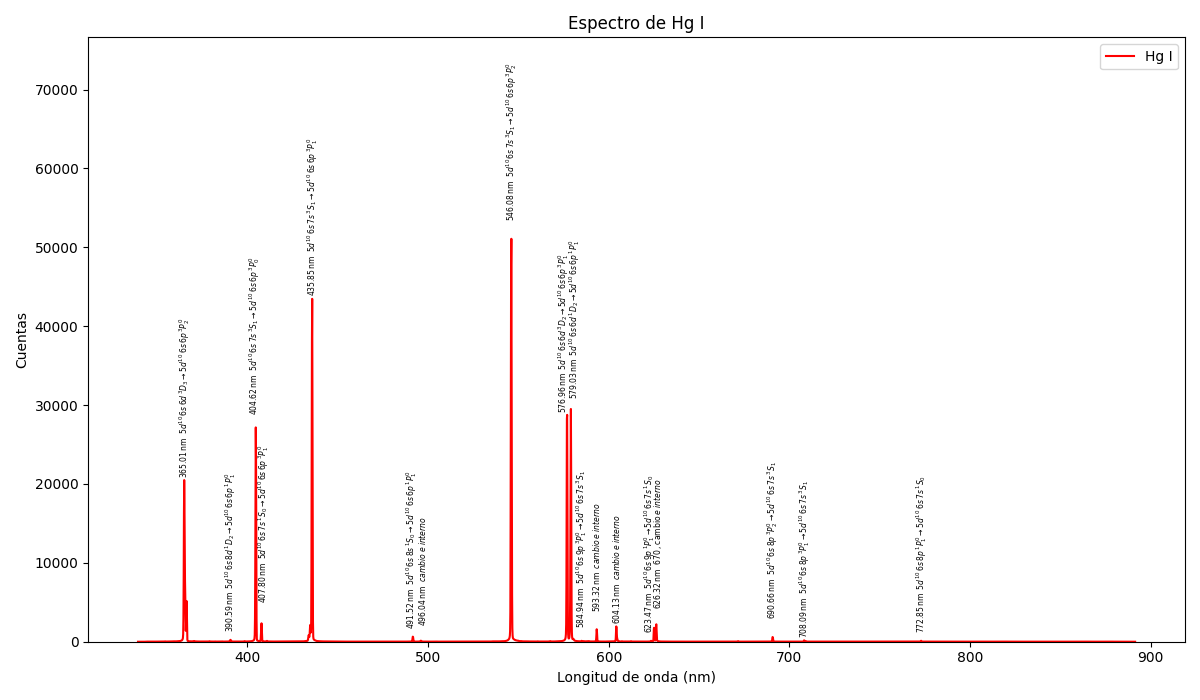

In [71]:
plt.figure(figsize=(12, 7))
plt.plot(Datos[:, 0], Datos[:, 4], label='Hg I', color='red')

# Líneas de Hg I en formato espectroscópico estándar
lineas_hg = [
    (365.01, r"5d^{10}\,6s\,6d\,^{3}D_{3}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{2}"),
    (390.59, r"5d^{10}\,6s\,8d\,^{1}D_{2}\rightarrow 5d^{10}\,6s\,6p\,^{1}P^{0}_{1}"),
    (404.62, r"5d^{10}\,6s\,7s\,^{3}S_{1}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{0}"),
    (407.80, r"5d^{10}\,6s\,7s\,^{1}S_{0}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{1}"),
    (435.85, r"5d^{10}\,6s\,7s\,^{3}S_{1}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{1}"),
    (491.52, r"5d^{10}\,6s\,8s\,^{1}S_{0}\rightarrow 5d^{10}\,6s\,6p\,^{1}P^{0}_{1}"),
    (496.04, r"cambio\;e\;interno"),
    (546.08, r"5d^{10}\,6s\,7s\,^{3}S_{1}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{2}"),
    (576.96, r"5d^{10}\,6s\,6d\,^{3}D_{2}\rightarrow 5d^{10}\,6s\,6p\,^{3}P^{0}_{1}"),
    (579.03, r"5d^{10}\,6s\,6d\,^{1}D_{2}\rightarrow 5d^{10}\,6s\,6p\,^{1}P^{0}_{1}"),
    (584.94, r"5d^{10}\,6s\,9p\,^{3}P^{0}_{1}\rightarrow 5d^{10}\,6s\,7s\,^{3}S_{1}"),
    (593.32, r"cambio\;e\;interno"),
    (604.13, r"cambio\;e\;interno"),
    (623.47, r"5d^{10}\,6s\,9p\,^{1}P^{0}_{1}\rightarrow 5d^{10}\,6s\,7s\,^{1}S_{0}"),
    (626.32, r"670\,\text{, cambio}\;e\;interno"),
    (690.66, r"5d^{10}\,6s\,8p\,^{3}P^{0}_{2}\rightarrow 5d^{10}\,6s\,7s\,^{3}S_{1}"),
    (708.09, r"5d^{10}\,6s\,8p\,^{3}P^{0}_{1}\rightarrow 5d^{10}\,6s\,7s\,^{3}S_{1}"),
    (772.85, r"5d^{10}\,6s\,8p\,^{1}P^{0}_{1}\rightarrow 5d^{10}\,6s\,7s\,^{1}S_{0}"),
]

lineas_ordenadas = sorted(lineas_hg, key=lambda t: t[0])
offset_vertical = [300, 950, 1600, 2250]

# Desplazamientos manuales para zonas especialmente densas
offset_x = {
    576.96: -1.0,
    579.03: 1,
    593.32: -0.35,
    604.13: 0.00,
    605.36: 0.35,
    623.47: -0.25,
    626.32: 0.25,
}

# Agrupación por cercanía para separar etiquetas
umbral_cluster_nm = 5.5
clusters = []
cluster_actual = [lineas_ordenadas[0]]

for item in lineas_ordenadas[1:]:
    if item[0] - cluster_actual[-1][0] <= umbral_cluster_nm:
        cluster_actual.append(item)
    else:
        clusters.append(cluster_actual)
        cluster_actual = [item]
clusters.append(cluster_actual)

offset_cluster = {}
for cluster in clusters:
    n = len(cluster)
    x_vals = np.linspace(-0.85, 0.85, n) if n > 1 else [0.0]
    for k, (lambda_nm, _) in enumerate(cluster):
        offset_cluster[round(lambda_nm, 2)] = (x_vals[k], 280 * k)

for i, (lambda_nm, transicion) in enumerate(lineas_ordenadas):
    idx = int(np.argmin(np.abs(Datos[:, 0] - lambda_nm)))
    y_pico = Datos[idx, 4]

    dx_c, dy_c = offset_cluster.get(round(lambda_nm, 2), (0.0, 0.0))
    dy = offset_vertical[i % len(offset_vertical)] + dy_c
    dx = offset_x.get(round(lambda_nm, 2), 0.0) + dx_c

    texto = rf"${lambda_nm:.2f}\,\mathrm{{nm}}\;\;{transicion}$"

    plt.text(
        lambda_nm + dx,
        y_pico + dy,
        texto,
        rotation=90,
        ha='center',
        va='bottom',
        fontsize=5.5,
        color='black',
        zorder=6
    )

plt.ylim(0, np.max(Datos[:, 4]) * 1.5)
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Cuentas')
plt.title('Espectro de Hg I')
plt.legend()
plt.tight_layout()
plt.show()

### Diagrama

Energías de los estados $^1S$ de Hg: [    0.   63928.12 74404.56 78404.24]
Energías de los estados $^1P$ de Hg: [54068.6829 71294.86   76863.137  79963.85  ]
Energías de los estados $^1D$ de Hg: [71333.053 77063.97  79660.56 ]
Energías de los estados $^3S$ de Hg: [62350.325 73961.135 78216.12 ]
Energías de los estados $^3P$ de Hg: [37644.982 39412.237 44042.909 69516.576 69661.803 71207.296 76447.112
 76466.936 76823.43  79375.652 79412.615 79611.7  ]
Energías de los estados $^3D$ de Hg: [71336.005 71396.073 71431.18  77084.42  77107.807 77129.372 79678.57
 79690.16  79702.53 ]


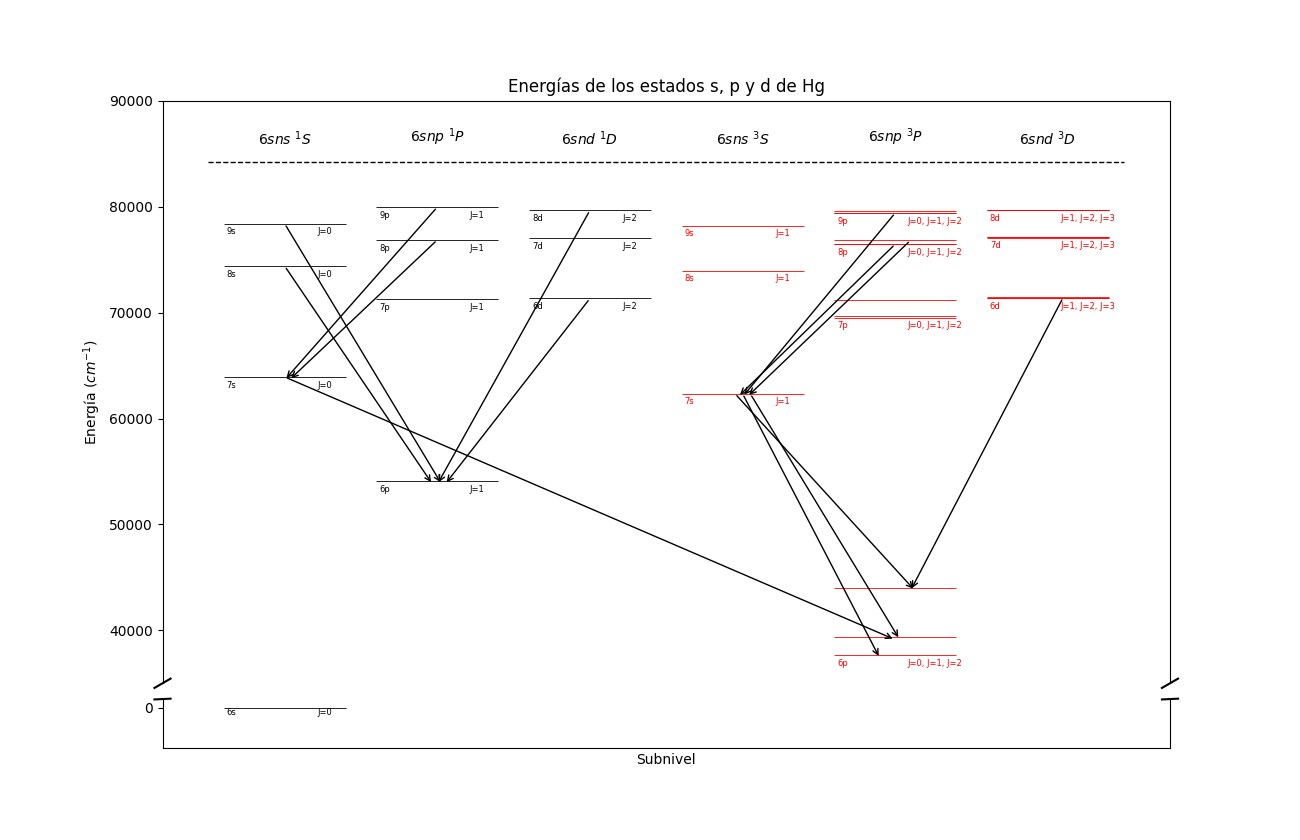

: 

: 

In [ ]:
Datos_Energia_s_Hg_1 =[]
Datos_Energia_p_Hg_1 =[]
Datos_Energia_d_Hg_1 =[]
Datos_Energia_s_Hg_3 =[]
Datos_Energia_p_Hg_3 =[]
Datos_Energia_d_Hg_3 =[]

"""6sns"""


for i in range(len(Data)):
        if Data.iloc[i, 13] == '3S':
                Datos_Energia_s_Hg_3.append(Data.iloc[i, 14])
        elif Data.iloc[i, 13] == '3P0':
                Datos_Energia_p_Hg_3.append(Data.iloc[i, 14])
                Datos_Energia_p_Hg_3.append(Data.iloc[i+1, 14])
                Datos_Energia_p_Hg_3.append(Data.iloc[i+2, 14])
        elif Data.iloc[i, 13] == '3D':
                Datos_Energia_d_Hg_3.append(Data.iloc[i, 14])
                Datos_Energia_d_Hg_3.append(Data.iloc[i+1, 14])
                Datos_Energia_d_Hg_3.append(Data.iloc[i+2, 14])
        elif Data.iloc[i, 13] == '1S':
                Datos_Energia_s_Hg_1.append(Data.iloc[i, 14])
        elif Data.iloc[i, 13] == '1P0':
                Datos_Energia_p_Hg_1.append(Data.iloc[i, 14])
        elif Data.iloc[i, 13] == '1D':
                Datos_Energia_d_Hg_1.append(Data.iloc[i, 14])



Energia_s_1 = np.array(Datos_Energia_s_Hg_1)
Energia_p_1 = np.array(Datos_Energia_p_Hg_1)
Energia_d_1 = np.array(Datos_Energia_d_Hg_1)
Energia_s_3 = np.array(Datos_Energia_s_Hg_3)
Energia_p_3 = np.array(Datos_Energia_p_Hg_3)
Energia_d_3 = np.array(Datos_Energia_d_Hg_3)

print(r'Energías de los estados $^1S$ de Hg:', Energia_s_1)
print(r'Energías de los estados $^1P$ de Hg:', Energia_p_1)
print(r'Energías de los estados $^1D$ de Hg:', Energia_d_1)
print(r'Energías de los estados $^3S$ de Hg:', Energia_s_3)
print(r'Energías de los estados $^3P$ de Hg:', Energia_p_3)
print(r'Energías de los estados $^3D$ de Hg:', Energia_d_3)

transiciones_hg = [
    # lambda = 365.01 nm (6d ³D -> 6p ³P⁰)
    (5.5, Energia_d_3[2], 4.5, Energia_p_3[2]), 
    
    # lambda = 390.59 nm (8d ¹D -> 6p ¹P⁰)
    (2.5, Energia_d_1[2], 1.5, Energia_p_1[0]), 
    
    # lambda = 404.62 nm (7s ³S -> 6p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[0]), 
    
    # lambda = 407.80 nm (7s ¹S -> 6p ³P⁰)
    (0.5, Energia_s_1[1], 4.5, Energia_p_3[1]), 
    
    # lambda = 410.83 nm (9s ¹S -> 6p ¹P⁰)
    (0.5, Energia_s_1[3], 1.5, Energia_p_1[0]), 
    
    # lambda = 435.85 nm (7s ³S -> 6p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[1]), 
    
    # lambda = 491.52 nm (8s ¹S -> 6p ¹P⁰)
    (0.5, Energia_s_1[2], 1.5, Energia_p_1[0]), 
    
    # lambda = 546.08 nm (7s ³S -> 6p ³P⁰)
    (3.5, Energia_s_3[0], 4.5, Energia_p_3[2]), 
    
    # lambda = 579.03 nm (6d ¹D -> 6p ¹P⁰)
    (2.5, Energia_d_1[0], 1.5, Energia_p_1[0]), 
    
    # lambda = 584.94 nm (9p ³P⁰ -> 7s ³S)
    (4.5, Energia_p_3[10], 3.5, Energia_s_3[0]), 
    
    # lambda = 623.47 nm (9p ¹P⁰ -> 7s ¹S)
    (1.5, Energia_p_1[3], 0.5, Energia_s_1[1]), 
    
    # lambda = 690.66 nm (8p ³P⁰ -> 7s ³S)
    (4.5, Energia_p_3[8], 3.5, Energia_s_3[0]), 
    
    # lambda = 708.09 nm (8p ³P⁰ -> 7s ³S)
    (4.5, Energia_p_3[7], 3.5, Energia_s_3[0]), 
    
    # lambda = 772.85 nm (8p ¹P⁰ -> 7s ¹S)
    (1.5, Energia_p_1[2], 0.5, Energia_s_1[1]), 
]

def idx_cercano(energias, y, tol=3.0):
    idx = int(np.argmin(np.abs(energias - y)))
    if abs(energias[idx] - y) <= tol:
        return idx
    return None

# Mismo diagrama pero con corte de eje Y y tramo alto desde 35000
fig, (ax_alto, ax_bajo) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(13, 8.4),
    gridspec_kw={"height_ratios": [6, 0.5], "hspace": 0.05}
)

for ax in (ax_alto, ax_bajo):
    ax.hlines(Energia_s_1, 0.1, 0.9, color='black', linewidth=0.6)
    ax.hlines(Energia_p_1, 1.1, 1.9, color='black', linewidth=0.6)
    ax.hlines(Energia_d_1, 2.1, 2.9, color='black', linewidth=0.6)
    ax.hlines(Energia_s_3, 3.1, 3.9, color='red', linewidth=0.6)
    ax.hlines(Energia_p_3, 4.1, 4.9, color='red', linewidth=0.6)
    ax.hlines(Energia_d_3, 5.1, 5.9, color='red', linewidth=0.6)

def offset_triplete_x(x, y):
    offset_map = [-0.1, 0.0, 0.1]
    if abs(x - 4.5) < 1e-9:
        idx = idx_cercano(Energia_p_3, y)
        if idx is not None:
            return offset_map[idx % 3]
    if abs(x - 5.5) < 1e-9:
        idx = idx_cercano(Energia_d_3, y)
        if idx is not None:
            return offset_map[idx % 3]
    return 0.0

repes = defaultdict(int)
repes_salida = defaultdict(int)
repes_llegada = defaultdict(int)
jitter_seq = [0.0, 0.02, -0.02, 0.035, -0.035]
jitter_salida_seq = [0.0, 0.05, -0.05, 0.08, -0.08]
jitter_llegada_seq = [0.0, 0.03, -0.03, 0.05, -0.05]

for x1, y1, x2, y2 in transiciones_hg:
    key = (round(x1, 3), round(y1, 3), round(x2, 3), round(y2, 3))
    j = jitter_seq[repes[key] % len(jitter_seq)]
    repes[key] += 1

    key_salida = (round(x1, 3), round(y1, 3))
    j_salida = jitter_salida_seq[repes_salida[key_salida] % len(jitter_salida_seq)]
    repes_salida[key_salida] += 1

    key_llegada = (round(x2, 3), round(y2, 3))
    j_llegada = jitter_llegada_seq[repes_llegada[key_llegada] % len(jitter_llegada_seq)]
    repes_llegada[key_llegada] += 1

    x1_of = x1 + offset_triplete_x(x1, y1) + j + j_salida
    x2_of = x2 + offset_triplete_x(x2, y2) + j + j_llegada

    ax_alto.annotate(
        "",
        xy=(x2_of, y2-300),
        xytext=(x1_of, y1),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
        zorder=5
    )

ax_alto.hlines(84184, 0, 6, color='black', linestyle='dashed', linewidth=1.0)

# Tramos visibles
ax_bajo.set_ylim(-7, 1.5)
ax_bajo.set_yticks([0])
ax_alto.set_ylim(35000, 90000)

# Etiquetas de nivel debajo de cada hline visible
labels_s1 = [f"{n}s" for n in range(6, 6 + len(Energia_s_1))]
labels_p1 = [f"{n}p" for n in range(6, 6 + len(Energia_p_1))]
labels_d1 = [f"{n}d" for n in range(6, 6 + len(Energia_d_1))]
labels_s3 = [f"{n}s" for n in range(7, 7 + len(Energia_s_3))]
labels_p3 = [f"{n}p" for n in range(6, 10) for _ in range(3)]
labels_d3 = [f"{n}d" for n in range(6, 9) for _ in range(3)]

def poner_etiquetas(ax, energias, x_izda, etiquetas, color='black', solo_inferior=False):
    y_lim_min, y_lim_max = ax.get_ylim()
    visibles = [(y, etiqueta) for y, etiqueta in zip(energias, etiquetas) if y_lim_min <= y <= y_lim_max]

    y_min_por_etiqueta = {}
    if solo_inferior:
        for y, etiqueta in visibles:
            if etiqueta not in y_min_por_etiqueta or y < y_min_por_etiqueta[etiqueta]:
                y_min_por_etiqueta[etiqueta] = y

    for y, etiqueta in visibles:
        if solo_inferior and abs(y - y_min_por_etiqueta[etiqueta]) > 1e-6:
            continue
        dy = 350 if y > 100 else 0.12
        ax.text(x_izda + 0.02, y - dy, etiqueta, ha='left', va='top', color=color, fontsize=6)

def poner_j_simple_abajo(ax, energias, x_centro, j_texto, color='black'):
    y_lim_min, y_lim_max = ax.get_ylim()
    for y in energias:
        if y_lim_min <= y <= y_lim_max:
            dy = 350 if y > 100 else 0.12
            ax.text(
                x_centro,
                y - dy,
                f"J={j_texto}",
                ha='center',
                va='top',
                fontsize=6,
                color=color,
                clip_on=True
            )

def poner_j_tripletes_abajo(ax, energias, x_centro, j1, j2, j3, color='black'):
    y_lim_min, y_lim_max = ax.get_ylim()
    for k in range(0, len(energias) - 2, 3):
        y_inf = min(energias[k], energias[k+1], energias[k+2])
        if y_lim_min <= y_inf <= y_lim_max:
            dy = 350 if y_inf > 100 else 0.12
            ax.text(
                x_centro,
                y_inf - dy,
                f"J={j1}, J={j2}, J={j3}",
                ha='center',
                va='top',
                fontsize=6,
                color=color,
                clip_on=True
            )

poner_etiquetas(ax_alto, Energia_s_1, 0.1, labels_s1, 'black')
poner_etiquetas(ax_alto, Energia_p_1, 1.1, labels_p1, 'black')
poner_etiquetas(ax_alto, Energia_d_1, 2.1, labels_d1, 'black')
poner_etiquetas(ax_alto, Energia_s_3, 3.1, labels_s3, 'red')
poner_etiquetas(ax_alto, Energia_p_3, 4.1, labels_p3, 'red', solo_inferior=True)
poner_etiquetas(ax_alto, Energia_d_3, 5.1, labels_d3, 'red', solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_s_1, 0.1, labels_s1, 'black')
poner_etiquetas(ax_bajo, Energia_p_1, 1.1, labels_p1, 'black')
poner_etiquetas(ax_bajo, Energia_d_1, 2.1, labels_d1, 'black')
poner_etiquetas(ax_bajo, Energia_s_3, 3.1, labels_s3, 'red')
poner_etiquetas(ax_bajo, Energia_p_3, 4.1, labels_p3, 'red', solo_inferior=True)
poner_etiquetas(ax_bajo, Energia_d_3, 5.1, labels_d3, 'red', solo_inferior=True)

# Etiquetas J: singletes y tripletes (tripletes en rojo)
poner_j_simple_abajo(ax_alto, Energia_s_1, 0.76, "0", color='black')
poner_j_simple_abajo(ax_bajo, Energia_s_1, 0.76, "0", color='black')
poner_j_simple_abajo(ax_alto, Energia_p_1, 1.76, "1", color='black')
poner_j_simple_abajo(ax_bajo, Energia_p_1, 1.76, "1", color='black')
poner_j_simple_abajo(ax_alto, Energia_d_1, 2.76, "2", color='black')
poner_j_simple_abajo(ax_bajo, Energia_d_1, 2.76, "2", color='black')

poner_j_simple_abajo(ax_alto, Energia_s_3, 3.76, "1", color='red')
poner_j_simple_abajo(ax_bajo, Energia_s_3, 3.76, "1", color='red')
poner_j_tripletes_abajo(ax_alto, Energia_p_3, 4.76, "0", "1", "2", color='red')
poner_j_tripletes_abajo(ax_bajo, Energia_p_3, 4.76, "0", "1", "2", color='red')
poner_j_tripletes_abajo(ax_alto, Energia_d_3, 5.76, "1", "2", "3", color='red')
poner_j_tripletes_abajo(ax_bajo, Energia_d_3, 5.76, "1", "2", "3", color='red')

# Eje roto
ax_alto.spines['bottom'].set_visible(False)
ax_bajo.spines['top'].set_visible(False)
ax_alto.tick_params(bottom=False, labelbottom=False)
ax_bajo.tick_params(top=False)

d = 0.008
kwargs = dict(transform=ax_alto.transAxes, color='k', clip_on=False)
ax_alto.plot((-d, +d), (-d, +d), **kwargs)
ax_alto.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bajo.transAxes)
ax_bajo.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bajo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bajo.set_xlabel('Subnivel')
ax_bajo.set_xticks([])
ax_alto.set_ylabel(r'Energía $(cm^{-1})$')
ax_alto.set_title('Diagrama de Grotian del Hg I')

ax_alto.text(0.5, 85500, r'$6sns \ ^1S$', ha='center', va='bottom')
ax_alto.text(1.5, 85500, r'$6snp \ ^1P$', ha='center', va='bottom')
ax_alto.text(2.5, 85500, r'$6snd \ ^1D$', ha='center', va='bottom')
ax_alto.text(3.5, 85500, r'$6sns \ ^3S$', ha='center', va='bottom')
ax_alto.text(4.5, 85500, r'$6snp \ ^3P$', ha='center', va='bottom')
ax_alto.text(5.5, 85500, r'$6snd \ ^3D$', ha='center', va='bottom')

plt.show()